In [5]:
%matplotlib widget

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import plotly.express as px

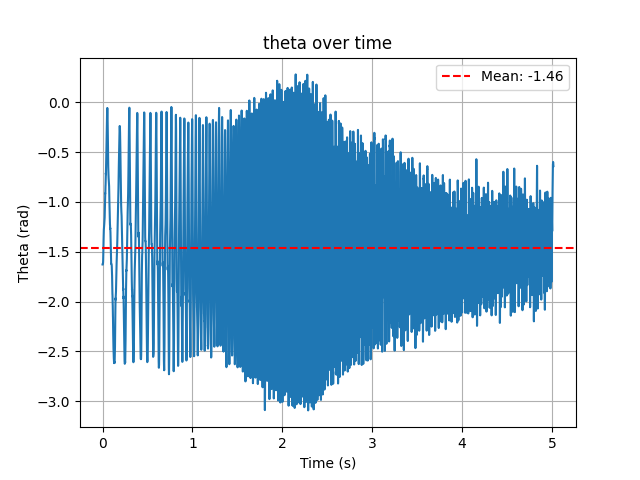

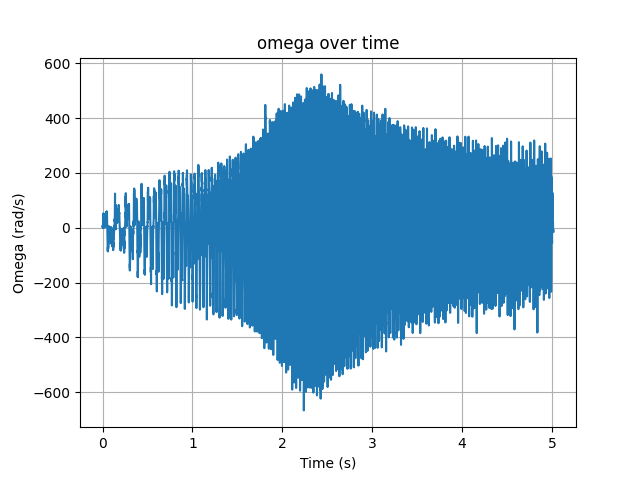

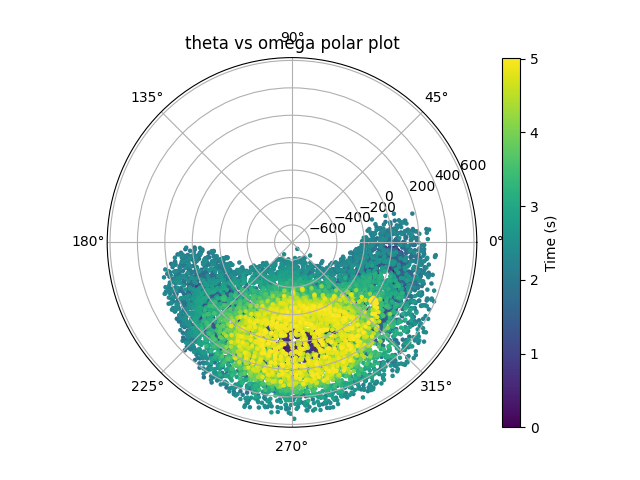

In [7]:
# Read tracking data
track_file = 'chirp-data/lube2-2.csv'
track_tbl = pd.read_csv(track_file, header=1)
t_trk = track_tbl.iloc[:, 0].values  # Var1
theta_trk = track_tbl.iloc[:, 3].values / 180 * np.pi  # Var4
omega_trk = track_tbl.iloc[:, 4].values / 180 * np.pi  # Var5

# Handle NaN values (backward fill first, then forward fill if needed)
# This handles NaN at the beginning by using the next valid value
omega_trk = pd.Series(omega_trk).bfill().ffill().values
theta_trk = pd.Series(theta_trk).bfill().ffill().values

# Plot theta over time
plt.figure()
plt.plot(t_trk, theta_trk)
plt.axhline(y=np.mean(theta_trk), color='r', linestyle='--', label=f'Mean: {np.mean(theta_trk):.2f}')
plt.title("theta over time")
plt.xlabel("Time (s)")
plt.ylabel("Theta (rad)")
plt.legend()
plt.grid(True)
plt.show()

# Plot omega over time
plt.figure()
plt.plot(t_trk, omega_trk)
plt.title("omega over time")
plt.xlabel("Time (s)")
plt.ylabel("Omega (rad/s)")
plt.grid(True)
plt.show()

# Polar scatter plot: theta vs omega
plt.figure()
ax = plt.subplot(111, projection='polar')
scatter = ax.scatter(theta_trk, omega_trk, c=t_trk, s=5, cmap='viridis')
plt.colorbar(scatter, label='Time (s)')
plt.title("theta vs omega polar plot")
plt.show()

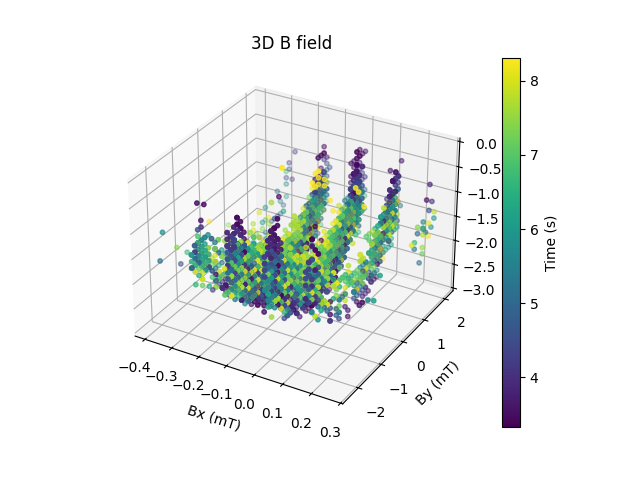

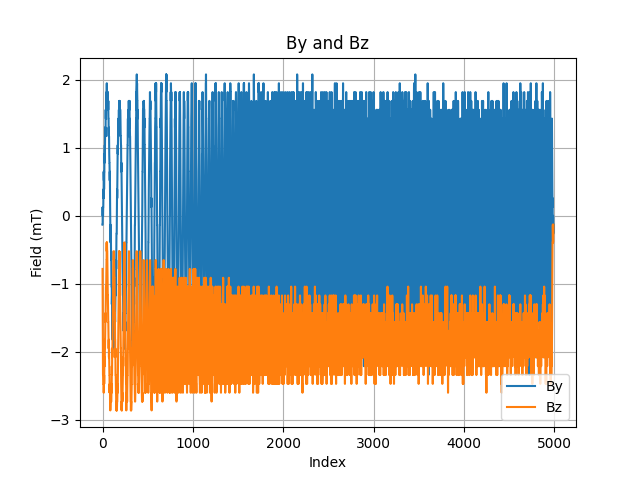

In [8]:
# Read field data
B_start = 3323
B_end = 8315

field_file = 'chirp2-lube.csv'
field_tbl = pd.read_csv(field_file, skiprows=7, sep=';')
idx = field_tbl['Index'].values
t_field = idx * 1e-3
t_field = t_field[B_start:B_end]

Bx = field_tbl['Bx[mT]'].values[B_start:B_end]
By = field_tbl['By[mT]'].values[B_start:B_end]
Bz = field_tbl['Bz[mT]'].values[B_start:B_end]

# 3D B field scatter
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(Bx, By, Bz, c=t_field, s=10, cmap='viridis')
plt.colorbar(scatter, label='Time (s)')
ax.set_xlabel('Bx (mT)')
ax.set_ylabel('By (mT)')
ax.set_zlabel('Bz (mT)')
plt.title("3D B field")
plt.show()

# Plot By and Bz
plt.figure()
plt.plot(By, label='By')
plt.plot(Bz, label='Bz')
plt.title("By and Bz")
plt.xlabel("Index")
plt.ylabel("Field (mT)")
plt.legend()
plt.grid(True)
plt.show()

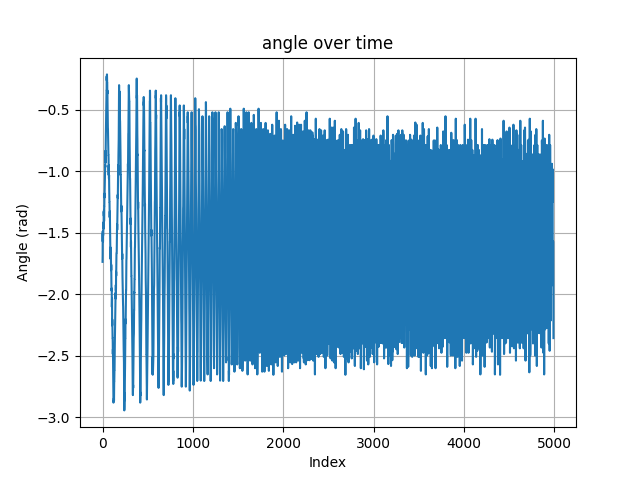

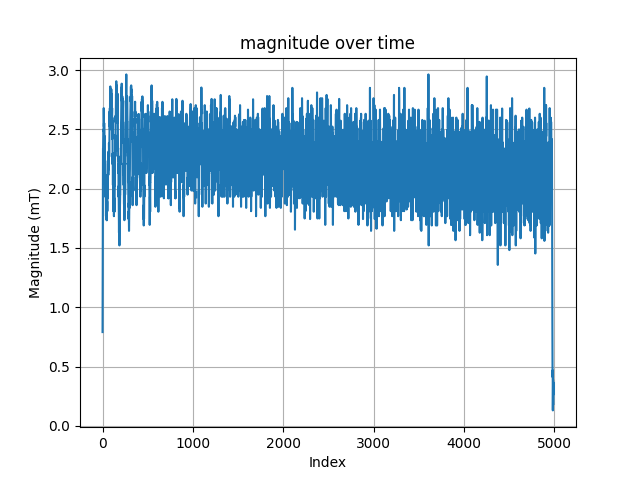

In [9]:
# Calculate angle and magnitude
theta_field = np.arctan2(Bz, By)
mag_field = np.linalg.norm([By, Bz], axis=0)

plt.figure()
plt.plot(theta_field)
plt.title("angle over time")
plt.xlabel("Index")
plt.ylabel("Angle (rad)")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(mag_field)
plt.title("magnitude over time")
plt.xlabel("Index")
plt.ylabel("Magnitude (mT)")
plt.grid(True)
plt.show()

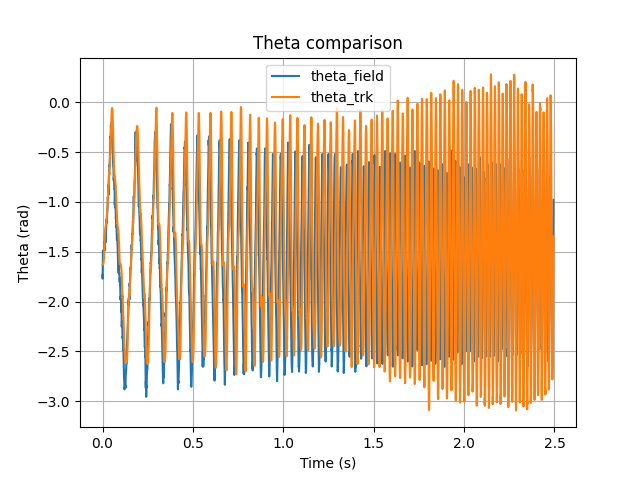

In [10]:
# Interpolate all data to 2kHz
fs_new = 2000
t_start = 0
t_end = 5
t_new = np.arange(t_start, t_end + 1/fs_new, 1/fs_new)

t_field_offset = t_field - t_field[0]

# Interpolate using spline
theta_field_spline = interp1d(t_field_offset, theta_field, kind='cubic', 
                               bounds_error=False, fill_value='extrapolate')(t_new)
mag_field_spline = interp1d(t_field_offset, mag_field, kind='cubic',
                            bounds_error=False, fill_value='extrapolate')(t_new)
omega_trk_spline = interp1d(t_trk, omega_trk, kind='cubic',
                            bounds_error=False, fill_value='extrapolate')(t_new)
# Use gradient to compute alpha (angular acceleration) - maintains array length
# Check for NaN in omega_trk_spline before computing gradient
if np.any(np.isnan(omega_trk_spline)):
    print(f"Warning: {np.sum(np.isnan(omega_trk_spline))} NaN values in omega_trk_spline")
    # Forward fill NaN values for gradient calculation
    omega_trk_spline_filled = omega_trk_spline.copy()
    nan_mask = np.isnan(omega_trk_spline_filled)
    if nan_mask[0]:  # If first value is NaN, backward fill
        omega_trk_spline_filled[0] = omega_trk_spline_filled[~nan_mask][0] if np.any(~nan_mask) else 0
    for i in range(1, len(omega_trk_spline_filled)):
        if nan_mask[i]:
            omega_trk_spline_filled[i] = omega_trk_spline_filled[i-1]
    omega_trk_spline = omega_trk_spline_filled
alpha_trk_spline = np.gradient(omega_trk_spline, t_new)
theta_trk_spline = interp1d(t_trk, theta_trk, kind='cubic',
                            bounds_error=False, fill_value='extrapolate')(t_new)

# Trim off a few ms (keep first 4990 points)
trim_idx = 4990
theta_field_trim = theta_field_spline[:trim_idx]
mag_field_trim = mag_field_spline[:trim_idx]
theta_trk_trim = theta_trk_spline[:trim_idx]
omega_trk_trim = omega_trk_spline[:trim_idx]
alpha_trk_trim = alpha_trk_spline[:trim_idx]
t_trim = t_new[:trim_idx]

# Plot theta comparison
plt.figure()
plt.plot(t_trim, theta_field_trim, label='theta_field')
plt.plot(t_trim, theta_trk_trim, label='theta_trk')
plt.title("Theta comparison")
plt.xlabel("Time (s)")
plt.ylabel("Theta (rad)")
plt.legend()
plt.grid(True)
plt.show()

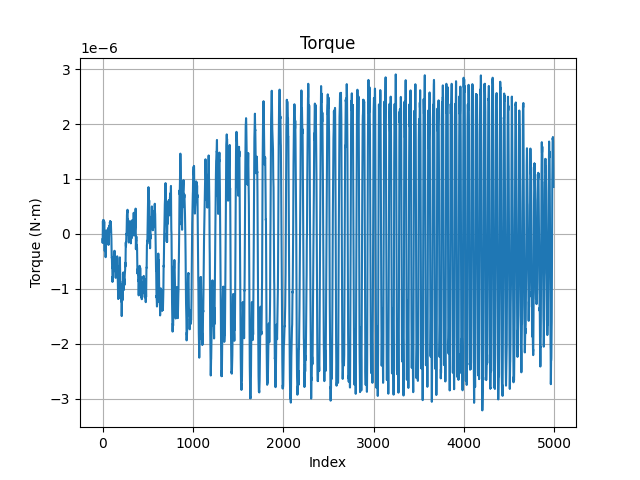

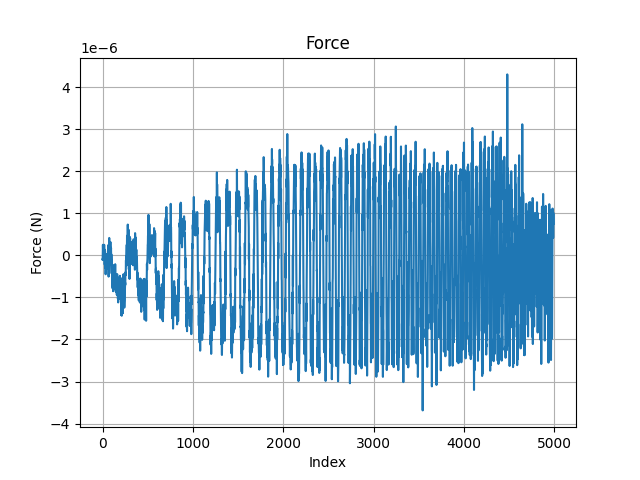

In [11]:
# Calculate torque and force
m = 1.4e-5
d = 2e-3
J = 1/6 * m * d**2
B_ext = mag_field_trim * 1e-3  # Convert mT to T
B_magnet = 0.00113  # A * m 62

B_const = B_magnet * B_ext
torque = B_const * np.sin(theta_field_trim - theta_trk_trim)

# Ensure arrays have same length
min_len = min(len(torque), len(alpha_trk_trim))
torque = torque[:min_len]
alpha_trk_trim = alpha_trk_trim[:min_len]

frc = torque - J * alpha_trk_trim

plt.figure()
plt.plot(torque)
plt.title("Torque")
plt.xlabel("Index")
plt.ylabel("Torque (N⋅m)")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(frc)
plt.title("Force")
plt.xlabel("Index")
plt.ylabel("Force (N)")
plt.grid(True)
plt.show()

Data shape: (4990, 2)
Input ranges:
  theta: [-3.0919, 0.2794] rad
  omega: [-666.0576, 559.3075] rad/s
  frc: [-3.685930e-06, 4.302331e-06] N

=== Polynomial Regression ===
Degree 2: Train R² = 0.3360, Test R² = 0.3062, Test RMSE = 1.164934e-06
Degree 3: Train R² = 0.5136, Test R² = 0.4655, Test RMSE = 1.022449e-06
Degree 4: Train R² = 0.5198, Test R² = 0.4778, Test RMSE = 1.010645e-06
Degree 5: Train R² = 0.6830, Test R² = 0.6661, Test RMSE = 8.080958e-07

Best polynomial model: Degree 5 (Test R² = 0.6661)


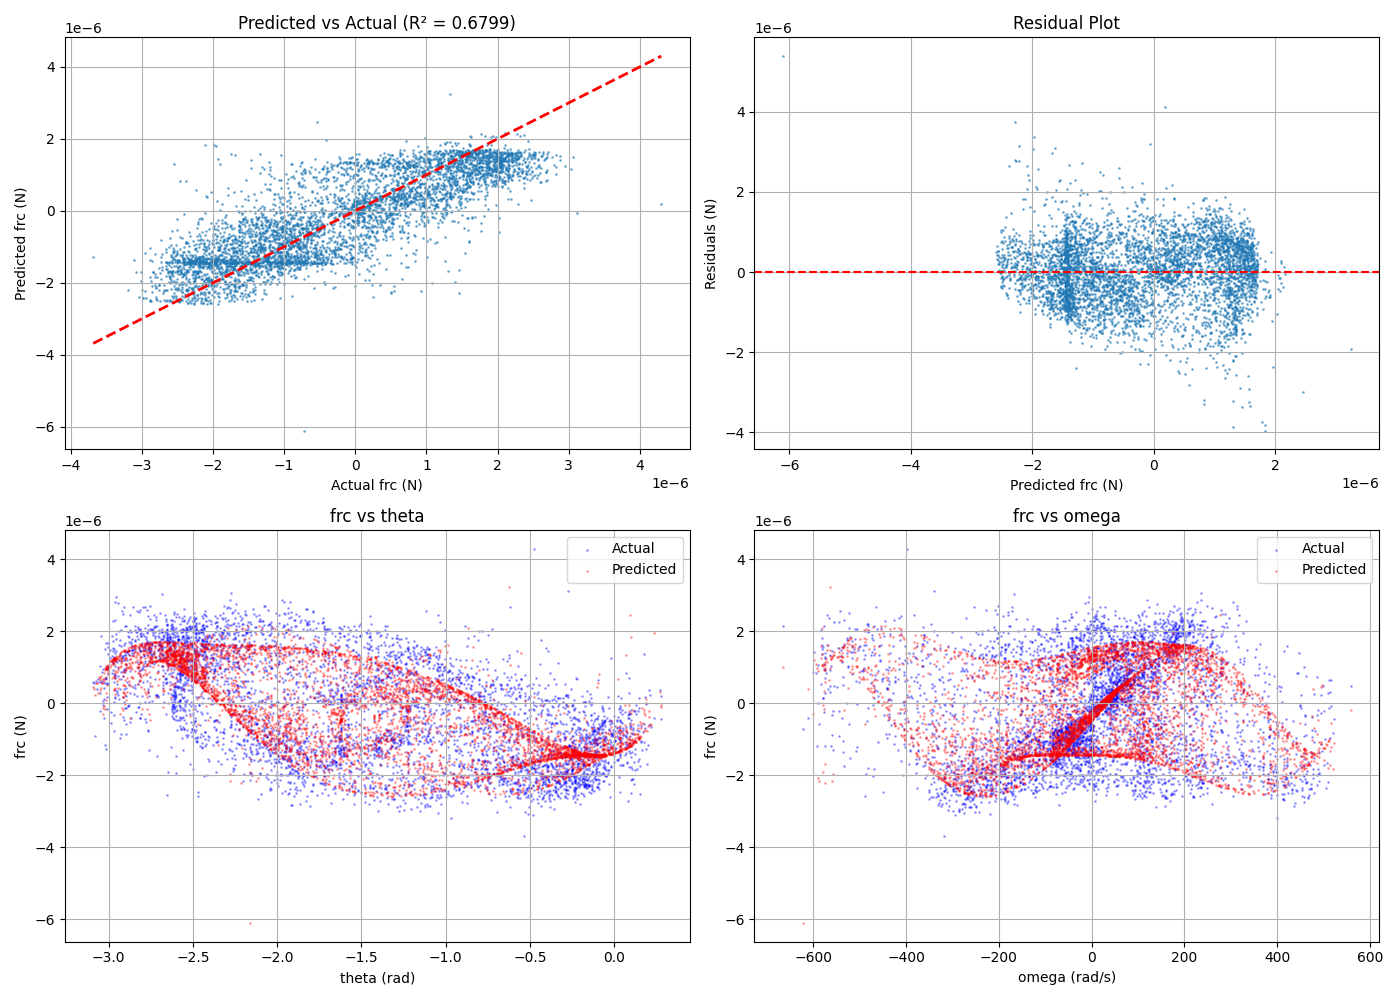


Model saved to frc_model_poly.pkl


In [12]:
# Fit frc as a function of theta and omega
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

# Prepare data: inputs (theta, omega) and output (frc)
X = np.column_stack([theta_trk_trim, omega_trk_trim])
y = frc

# Remove any NaN or inf values
valid_mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
X_clean = X[valid_mask]
y_clean = y[valid_mask]

print(f"Data shape: {X_clean.shape}")
print(f"Input ranges:")
print(f"  theta: [{X_clean[:, 0].min():.4f}, {X_clean[:, 0].max():.4f}] rad")
print(f"  omega: [{X_clean[:, 1].min():.4f}, {X_clean[:, 1].max():.4f}] rad/s")
print(f"  frc: [{y_clean.min():.6e}, {y_clean.max():.6e}] N")

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

# Method 1: Polynomial Regression
print("\n=== Polynomial Regression ===")
degrees = [2, 3, 4, 5]
best_poly_score = -np.inf
best_poly_degree = None
best_poly_model = None

for degree in degrees:
    poly_model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=True)),
        ('scaler', StandardScaler()),
        ('reg', LinearRegression())
    ])
    poly_model.fit(X_train, y_train)
    
    y_train_pred = poly_model.predict(X_train)
    y_test_pred = poly_model.predict(X_test)
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    print(f"Degree {degree}: Train R² = {train_r2:.4f}, Test R² = {test_r2:.4f}, Test RMSE = {test_rmse:.6e}")
    
    if test_r2 > best_poly_score:
        best_poly_score = test_r2
        best_poly_degree = degree
        best_poly_model = poly_model

print(f"\nBest polynomial model: Degree {best_poly_degree} (Test R² = {best_poly_score:.4f})")

# Visualize the fit
y_pred_all = best_poly_model.predict(X_clean)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Predicted vs Actual
axes[0, 0].scatter(y_clean, y_pred_all, alpha=0.5, s=1)
axes[0, 0].plot([y_clean.min(), y_clean.max()], [y_clean.min(), y_clean.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual frc (N)')
axes[0, 0].set_ylabel('Predicted frc (N)')
axes[0, 0].set_title(f'Predicted vs Actual (R² = {r2_score(y_clean, y_pred_all):.4f})')
axes[0, 0].grid(True)

# Plot 2: Residuals
residuals = y_clean - y_pred_all
axes[0, 1].scatter(y_pred_all, residuals, alpha=0.5, s=1)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicted frc (N)')
axes[0, 1].set_ylabel('Residuals (N)')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(True)

# Plot 3: frc vs theta
axes[1, 0].scatter(X_clean[:, 0], y_clean, alpha=0.3, s=1, label='Actual', color='blue')
axes[1, 0].scatter(X_clean[:, 0], y_pred_all, alpha=0.3, s=1, label='Predicted', color='red')
axes[1, 0].set_xlabel('theta (rad)')
axes[1, 0].set_ylabel('frc (N)')
axes[1, 0].set_title('frc vs theta')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot 4: frc vs omega
axes[1, 1].scatter(X_clean[:, 1], y_clean, alpha=0.3, s=1, label='Actual', color='blue')
axes[1, 1].scatter(X_clean[:, 1], y_pred_all, alpha=0.3, s=1, label='Predicted', color='red')
axes[1, 1].set_xlabel('omega (rad/s)')
axes[1, 1].set_ylabel('frc (N)')
axes[1, 1].set_title('frc vs omega')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Save the model
import pickle
model_filename = 'frc_model_poly.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(best_poly_model, f)
print(f"\nModel saved to {model_filename}")

# Print model coefficients (for degree 2 as example)
if best_poly_degree == 2:
    print("\nModel coefficients (for degree 2):")
    print("frc = c0 + c1*theta + c2*omega + c3*theta² + c4*theta*omega + c5*omega²")
    coef = best_poly_model.named_steps['reg'].coef_
    intercept = best_poly_model.named_steps['reg'].intercept_
    feature_names = best_poly_model.named_steps['poly'].get_feature_names_out(['theta', 'omega'])
    print(f"Intercept: {intercept:.6e}")
    for name, c in zip(feature_names, coef):
        if abs(c) > 1e-10:  # Only print significant coefficients
            print(f"  {name}: {c:.6e}")

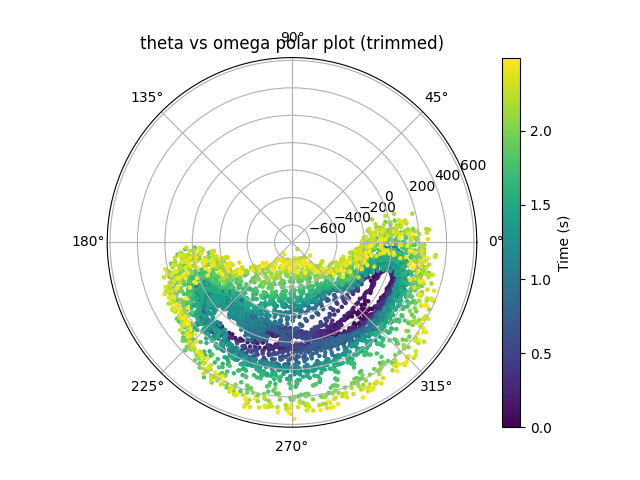

In [13]:
# 3D scatter: omega components vs force
# Offset omega by its minimum to match polar plot radius range behavior
# This prevents reflection: min omega maps to inner radius, max to outer radius
omega_min = omega_trk_trim.min()
omega_offset = omega_trk_trim - omega_min  # Now ranges from 0 to (max - min)
xs = omega_offset * np.cos(theta_trk_trim)
ys = omega_offset * np.sin(theta_trk_trim)
zs = frc * 1e8

# Use Plotly for interactive 3D plot (much faster and smoother)
fig = go.Figure(data=go.Scatter3d(
    x=xs,
    y=ys,
    z=zs,
    mode='markers',
    marker=dict(
        size=3,
        color=t_trim,
        colorscale='Viridis',
        colorbar=dict(title='Time (s)'),
        opacity=0.8
    ),
    hovertemplate='<b>ω cos(θ)</b>: %{x:.4f}<br>' +
                  '<b>ω sin(θ)</b>: %{y:.4f}<br>' +
                  '<b>Force × 1e8</b>: %{z:.4f}<br>' +
                  '<b>Time</b>: %{marker.color:.4f} s<extra></extra>'
))

# Set axis ranges based on actual data
x_range = [xs.min(), xs.max()]
y_range = [ys.min(), ys.max()]
z_range = [zs.min(), zs.max()]

# Add small padding
x_pad = (x_range[1] - x_range[0]) * 0.05 if (x_range[1] - x_range[0]) > 0 else 0.1
y_pad = (y_range[1] - y_range[0]) * 0.05 if (y_range[1] - y_range[0]) > 0 else 0.1
z_pad = (z_range[1] - z_range[0]) * 0.05 if (z_range[1] - z_range[0]) > 0 else 0.1

fig.update_layout(
    title='3D: omega components vs force',
    scene=dict(
        xaxis_title='ω cos(θ)',
        yaxis_title='ω sin(θ)',
        zaxis_title='Force × 1e8',
        xaxis=dict(range=[x_range[0] - x_pad, x_range[1] + x_pad]),
        yaxis=dict(range=[y_range[0] - y_pad, y_range[1] + y_pad]),
        zaxis=dict(range=[z_range[0] - z_pad, z_range[1] + z_pad]),
        aspectmode='data'  # Each axis scales independently
    ),
    width=800,
    height=600
)

fig.show()

# Polar scatter: theta vs omega with time color
plt.figure()
ax = plt.subplot(111, projection='polar')
scatter = ax.scatter(theta_trk_trim, omega_trk_trim, c=t_trim, s=5, cmap='viridis')
plt.colorbar(scatter, label='Time (s)')
plt.title("theta vs omega polar plot (trimmed)")
plt.show()

Data shape: (4990, 2)
Input ranges:
  theta: [-3.0919, 0.2794] rad
  omega (r): [-666.0576, 559.3075] rad/s
  frc (z): [-3.685930e-06, 4.302331e-06] N

=== Two-Stage Cylindrical Fitting: (r,θ)→(x,y), then z=poly(x,y) ===
r_deg=2, θ_deg=1, z_poly_deg=2, n_params=10: Train R²=0.5079, Test R²=0.4739, Test RMSE=1.014470e-06
r_deg=2, θ_deg=1, z_poly_deg=3, n_params=10: Train R²=0.6041, Test R²=0.5772, Test RMSE=9.093508e-07
r_deg=2, θ_deg=1, z_poly_deg=4, n_params=10: Train R²=0.6028, Test R²=0.5784, Test RMSE=9.080698e-07
r_deg=2, θ_deg=2, z_poly_deg=2, n_params=12: Train R²=0.4889, Test R²=0.4303, Test RMSE=1.055598e-06
r_deg=2, θ_deg=2, z_poly_deg=3, n_params=12: Train R²=0.5548, Test R²=0.5413, Test RMSE=9.471980e-07
r_deg=2, θ_deg=2, z_poly_deg=4, n_params=12: Train R²=0.6722, Test R²=0.6656, Test RMSE=8.087696e-07
r_deg=2, θ_deg=3, z_poly_deg=2, n_params=14: Train R²=0.5635, Test R²=0.5215, Test RMSE=9.674614e-07
r_deg=2, θ_deg=3, z_poly_deg=3, n_params=14: Train R²=0.6068, Test R²=0.

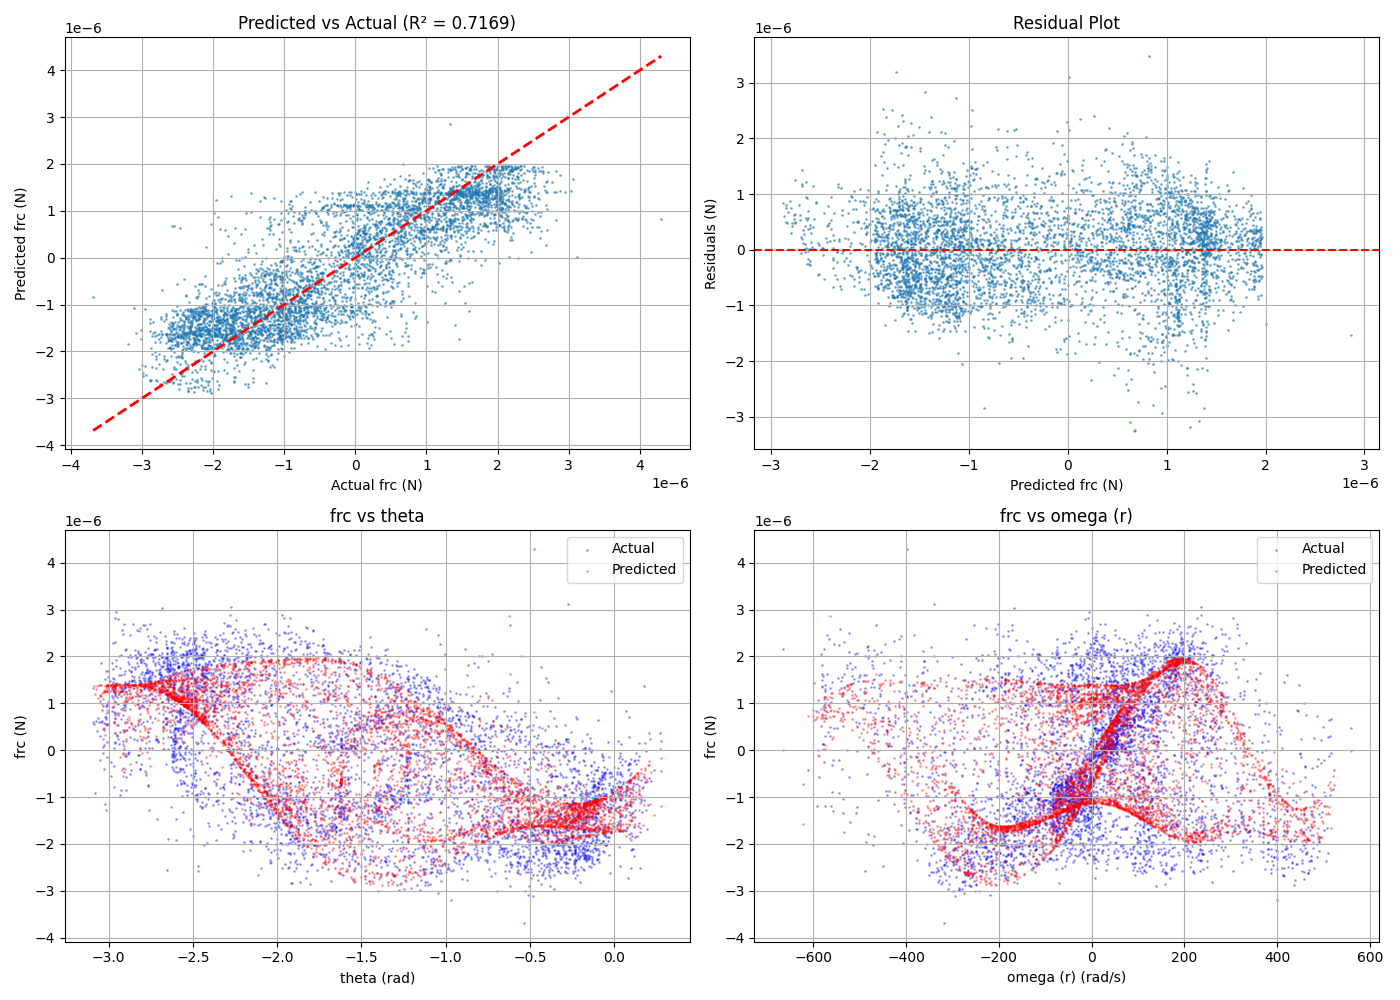

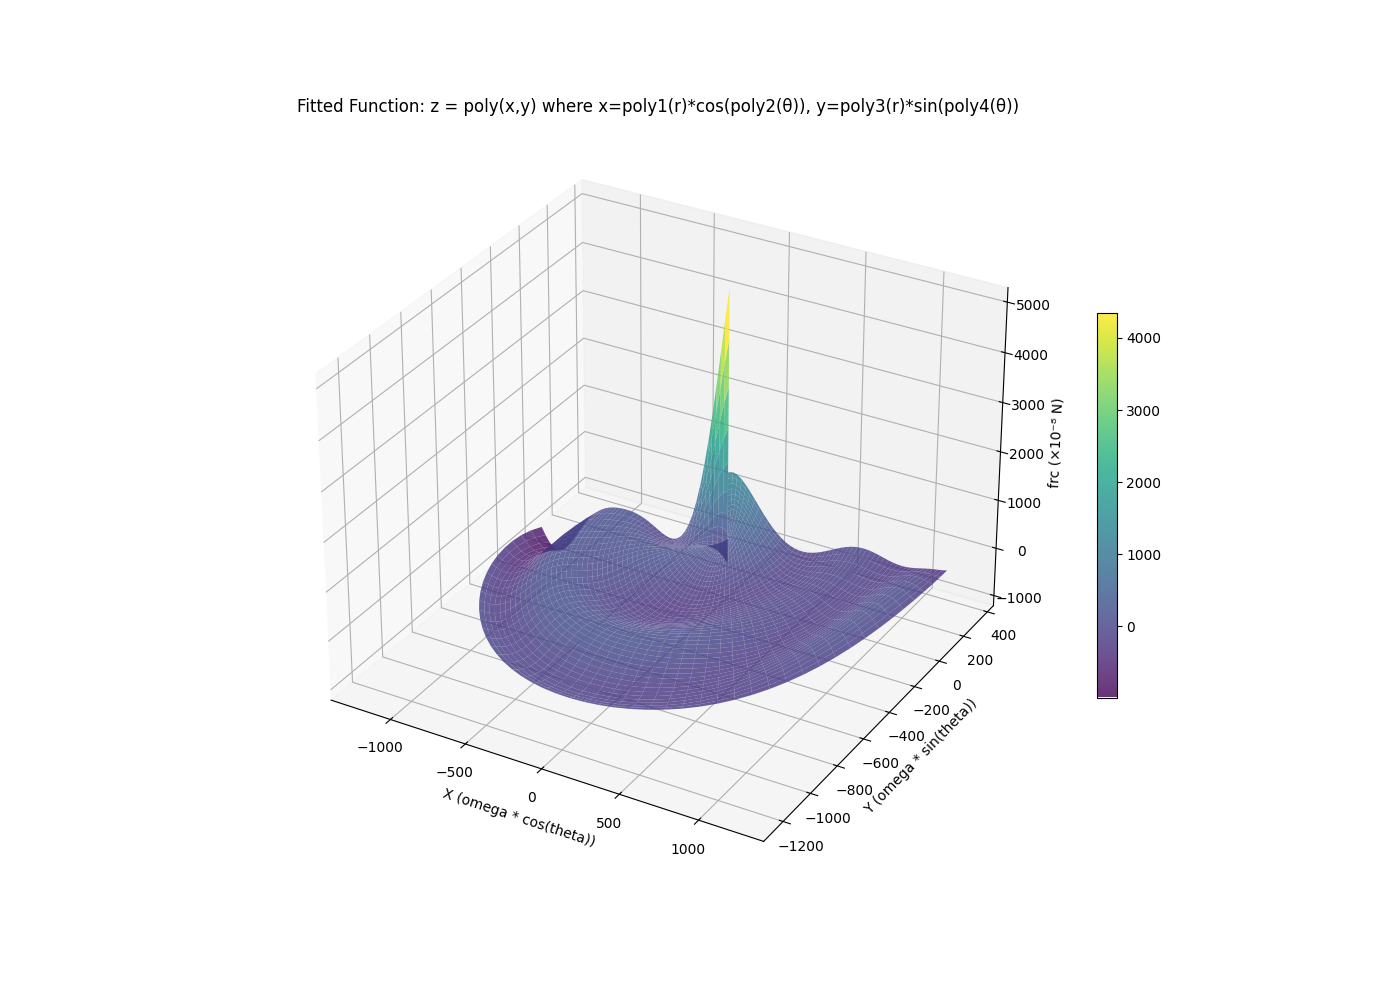

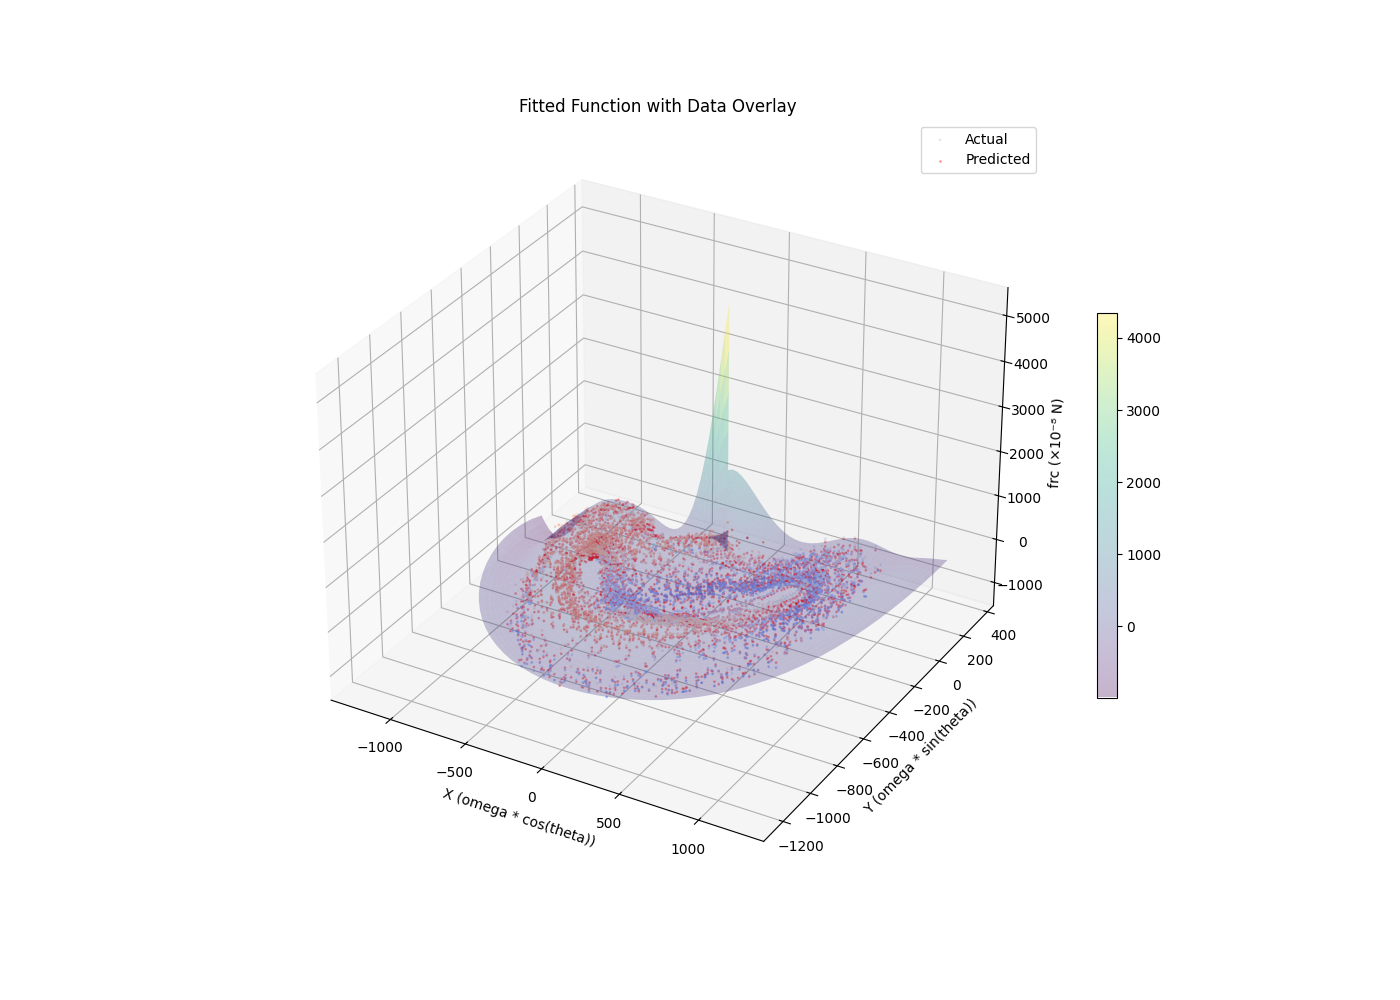


Model saved to frc_model_cylindrical.pkl

Model form:
  Stage 1: x = poly1(r) * cos(poly2(θ)), y = poly3(r) * sin(poly4(θ))
  Stage 2: z = poly5(x, y)
Parameters: r_degree=4, θ_degree=3, z_poly_degree=4
r normalization: [-666.057611, 559.307514]
theta normalization: [-3.091938, 0.279356]

Transformation coefficients:
poly1(r) coefficients (for x):
  r^0: 1.944610e-01
  r^1: -6.896509e-01
  r^2: -4.154702e-01
  r^3: 3.917299e-01
  r^4: 1.548280e-01

poly2(θ) coefficients (for x):
  θ^0: 8.806657e-01
  θ^1: 1.089275e+00
  θ^2: -9.118461e-01
  θ^3: 1.149490e-01

poly3(r) coefficients (for y):
  r^0: -8.875767e-01
  r^1: -4.721035e-01
  r^2: 5.612123e-01
  r^3: -1.327316e+00
  r^4: 9.105924e-01

poly4(θ) coefficients (for y):
  θ^0: 5.563072e-01
  θ^1: -1.449800e-01
  θ^2: 3.639623e-01
  θ^3: -1.948327e-01

z = poly(x,y) model coefficients:
Intercept: -2.136168e-07
Significant coefficients:
  x: -1.830698e-02
  y: 4.851208e-02
  x^2: -1.526432e-03
  x y: -5.287115e-02
  y^2: 1.451240e-01


In [14]:
# Fit frc as a function of r (omega) and theta in cylindrical coordinates
# Two-stage model:
# Stage 1: Transform (r,θ) → (x,y) where:
#   x = poly1(r) * cos(poly2(θ))
#   y = poly3(r) * sin(poly4(θ))
# Stage 2: Fit z = poly5(x, y)
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize
import pickle

def transform_rtheta_to_xy(params, r, theta, r_degree, theta_degree):
    """
    Transform (r,θ) to (x,y) using:
    x = poly1(r) * cos(poly2(θ))
    y = poly3(r) * sin(poly4(θ))
    
    Parameters:
    - params: flattened array [poly1_coef, poly2_coef, poly3_coef, poly4_coef]
    - r: radius values (omega)
    - theta: angle values
    - r_degree: degree of polynomials in r (poly1, poly3)
    - theta_degree: degree of polynomials in theta (poly2, poly4)
    """
    n_r_coef = r_degree + 1
    n_theta_coef = theta_degree + 1
    
    # Extract coefficients
    poly1_coef = params[:n_r_coef]  # for x: poly1(r)
    poly2_coef = params[n_r_coef:n_r_coef + n_theta_coef]  # for x: poly2(θ)
    poly3_coef = params[n_r_coef + n_theta_coef:2 * n_r_coef + n_theta_coef]  # for y: poly3(r)
    poly4_coef = params[2 * n_r_coef + n_theta_coef:]  # for y: poly4(θ)
    
    # Evaluate polynomials
    poly1_r = np.polyval(poly1_coef[::-1], r)
    poly2_theta = np.polyval(poly2_coef[::-1], theta)
    poly3_r = np.polyval(poly3_coef[::-1], r)
    poly4_theta = np.polyval(poly4_coef[::-1], theta)
    
    # Compute x and y
    x = poly1_r * np.cos(poly2_theta)
    y = poly3_r * np.sin(poly4_theta)
    
    return np.column_stack([x, y])

def objective_function(params, r, theta, z_true, r_degree, theta_degree, z_poly_degree):
    """
    Objective: maximize R² of z = poly(x,y) fit
    Returns negative R² (to minimize) - we want to maximize R²
    """
    # Transform to (x,y)
    xy = transform_rtheta_to_xy(params, r, theta, r_degree, theta_degree)
    
    # Fit z as polynomial in (x,y)
    poly_features = PolynomialFeatures(degree=z_poly_degree, include_bias=True)
    X_poly = poly_features.fit_transform(xy)
    
    # Linear regression
    reg = LinearRegression()
    reg.fit(X_poly, z_true)
    
    # Predict and compute R²
    z_pred = reg.predict(X_poly)
    r2 = r2_score(z_true, z_pred)
    
    # Return negative R² (to minimize) - we want to maximize R²
    return -r2

# Prepare data: inputs (theta, omega) and output (frc)
# In cylindrical coords: r = omega, θ = theta, z = frc
X = np.column_stack([theta_trk_trim, omega_trk_trim])
y = frc

# Remove any NaN or inf values
valid_mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
X_clean = X[valid_mask]
y_clean = y[valid_mask]

print(f"Data shape: {X_clean.shape}")
print(f"Input ranges:")
print(f"  theta: [{X_clean[:, 0].min():.4f}, {X_clean[:, 0].max():.4f}] rad")
print(f"  omega (r): [{X_clean[:, 1].min():.4f}, {X_clean[:, 1].max():.4f}] rad/s")
print(f"  frc (z): [{y_clean.min():.6e}, {y_clean.max():.6e}] N")

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

# Try different combinations of r_degree, theta_degree, and z_poly_degree
print("\n=== Two-Stage Cylindrical Fitting: (r,θ)→(x,y), then z=poly(x,y) ===")
best_score = -np.inf
best_transform_params = None
best_z_model = None
best_params = None

# Search over parameter combinations
r_degrees = [2, 3, 4]
theta_degrees = [1, 2, 3]
z_poly_degrees = [2, 3, 4]  # degree of polynomial for z = poly(x,y)

# Normalize r and theta for better numerical conditioning
r_train = X_train[:, 1]
r_test = X_test[:, 1]
r_all = X_clean[:, 1]
r_min, r_max = r_all.min(), r_all.max()
r_train_norm = (r_train - r_min) / (r_max - r_min + 1e-10)
r_test_norm = (r_test - r_min) / (r_max - r_min + 1e-10)
r_all_norm = (r_all - r_min) / (r_max - r_min + 1e-10)

theta_train = X_train[:, 0]
theta_test = X_test[:, 0]
theta_all = X_clean[:, 0]
theta_min, theta_max = theta_all.min(), theta_all.max()
theta_train_norm = (theta_train - theta_min) / (theta_max - theta_min + 1e-10)
theta_test_norm = (theta_test - theta_min) / (theta_max - theta_min + 1e-10)
theta_all_norm = (theta_all - theta_min) / (theta_max - theta_min + 1e-10)

for r_deg in r_degrees:
    for theta_deg in theta_degrees:
        for z_poly_deg in z_poly_degrees:
            # Number of parameters: 2*(r_degree+1) for poly1 and poly3, 2*(theta_degree+1) for poly2 and poly4
            n_params = 2 * (r_deg + 1) + 2 * (theta_deg + 1)
            
            # Initialize parameters (small random values)
            np.random.seed(42)
            params0 = np.random.randn(n_params) * 0.01
            
                        # Optimize transformation to maximize R² of z = poly(x,y) fit
            result = minimize(
                objective_function,
                params0,
                args=(r_train_norm, theta_train_norm, y_train, r_deg, theta_deg, z_poly_deg),
                method='BFGS',
                options={'maxiter': 100}
            )
            
                        # Transform to (x,y) using optimized parameters
            xy_train = transform_rtheta_to_xy(result.x, r_train_norm, theta_train_norm, r_deg, theta_deg)
            xy_test = transform_rtheta_to_xy(result.x, r_test_norm, theta_test_norm, r_deg, theta_deg)
            
            # Fit z as polynomial in (x,y)
            z_model = Pipeline([
                ('poly', PolynomialFeatures(degree=z_poly_deg, include_bias=True)),
                ('scaler', StandardScaler()),
                ('reg', LinearRegression())
            ])
            z_model.fit(xy_train, y_train)
            
            # Evaluate on train and test sets
            y_train_pred = z_model.predict(xy_train)
            y_test_pred = z_model.predict(xy_test)
            
            train_r2 = r2_score(y_train, y_train_pred)
            test_r2 = r2_score(y_test, y_test_pred)
            test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
            
            print(f"r_deg={r_deg}, θ_deg={theta_deg}, z_poly_deg={z_poly_deg}, n_params={n_params}: "
                  f"Train R²={train_r2:.4f}, Test R²={test_r2:.4f}, Test RMSE={test_rmse:.6e}")
            
            if test_r2 > best_score:
                best_score = test_r2
                best_transform_params = result.x
                best_z_model = z_model
                best_params = (r_deg, theta_deg, z_poly_deg, r_min, r_max, theta_min, theta_max)

print(f"\nBest model: r_degree={best_params[0]}, θ_degree={best_params[1]}, z_poly_degree={best_params[2]} "
      f"(Test R² = {best_score:.4f})")

# Visualize the fit
r_deg, theta_deg, z_poly_deg, r_min_best, r_max_best, theta_min_best, theta_max_best = best_params
r_all_norm_best = (r_all - r_min_best) / (r_max_best - r_min_best + 1e-10)
theta_all_norm_best = (theta_all - theta_min_best) / (theta_max_best - theta_min_best + 1e-10)
xy_all = transform_rtheta_to_xy(best_transform_params, r_all_norm_best, theta_all_norm_best, r_deg, theta_deg)
y_pred_all = best_z_model.predict(xy_all)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Predicted vs Actual
axes[0, 0].scatter(y_clean, y_pred_all, alpha=0.5, s=1)
axes[0, 0].plot([y_clean.min(), y_clean.max()], [y_clean.min(), y_clean.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual frc (N)')
axes[0, 0].set_ylabel('Predicted frc (N)')
axes[0, 0].set_title(f'Predicted vs Actual (R² = {r2_score(y_clean, y_pred_all):.4f})')
axes[0, 0].grid(True)

# Plot 2: Residuals
residuals = y_clean - y_pred_all
axes[0, 1].scatter(y_pred_all, residuals, alpha=0.5, s=1)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicted frc (N)')
axes[0, 1].set_ylabel('Residuals (N)')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(True)

# Plot 3: frc vs theta
axes[1, 0].scatter(X_clean[:, 0], y_clean, alpha=0.3, s=1, label='Actual', color='blue')
axes[1, 0].scatter(X_clean[:, 0], y_pred_all, alpha=0.3, s=1, label='Predicted', color='red')
axes[1, 0].set_xlabel('theta (rad)')
axes[1, 0].set_ylabel('frc (N)')
axes[1, 0].set_title('frc vs theta')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot 4: frc vs omega (r)
axes[1, 1].scatter(X_clean[:, 1], y_clean, alpha=0.3, s=1, label='Actual', color='blue')
axes[1, 1].scatter(X_clean[:, 1], y_pred_all, alpha=0.3, s=1, label='Predicted', color='red')
axes[1, 1].set_xlabel('omega (r) (rad/s)')
axes[1, 1].set_ylabel('frc (N)')
axes[1, 1].set_title('frc vs omega (r)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# 3D visualization of the fitted function
# Create a grid of (r, theta) values
r_grid = np.linspace(r_all.min(), r_all.max(), 50)
theta_grid = np.linspace(theta_all.min(), theta_all.max(), 50)
R_grid, Theta_grid = np.meshgrid(r_grid, theta_grid)

# Normalize grid values
R_grid_norm = (R_grid - r_min_best) / (r_max_best - r_min_best + 1e-10)
Theta_grid_norm = (Theta_grid - theta_min_best) / (theta_max_best - theta_min_best + 1e-10)

# Transform to (x,y)
R_flat = R_grid_norm.flatten()
Theta_flat = Theta_grid_norm.flatten()
xy_grid = transform_rtheta_to_xy(best_transform_params, R_flat, Theta_flat, r_deg, theta_deg)

# Predict z on grid
Z_grid_flat = best_z_model.predict(xy_grid)
Z_grid = Z_grid_flat.reshape(R_grid.shape)

# Convert to Cartesian for 3D plot with radius offset (to match polar plot behavior)
# Offset radius so min radius maps to origin, preventing reflection
R_grid_offset = R_grid - r_min_best  # Now ranges from 0 to (max - min)
X_grid = R_grid_offset * np.cos(Theta_grid)
Y_grid = R_grid_offset * np.sin(Theta_grid)

# Create 3D surface plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X_grid, Y_grid, Z_grid * 1e8, cmap='viridis', alpha=0.8, linewidth=0, antialiased=True)
ax.set_xlabel('X (omega * cos(theta))')
ax.set_ylabel('Y (omega * sin(theta))')
ax.set_zlabel('frc (×10⁻⁸ N)')
ax.set_title('Fitted Function: z = poly(x,y) where x=poly1(r)*cos(poly2(θ)), y=poly3(r)*sin(poly4(θ))')
plt.colorbar(surf, ax=ax, shrink=0.5, aspect=20)
plt.show()

# Also create a scatter plot overlay with actual data
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')
# Plot surface
surf = ax.plot_surface(X_grid, Y_grid, Z_grid * 1e8, cmap='viridis', alpha=0.3, linewidth=0, antialiased=True)
# Plot actual data points with radius offset (to match polar plot behavior)
r_all_offset = r_all - r_min_best  # Offset so min radius maps to origin
xs_actual = r_all_offset * np.cos(theta_all)
ys_actual = r_all_offset * np.sin(theta_all)
ax.scatter(xs_actual, ys_actual, y_clean * 1e8, c=y_clean * 1e8, cmap='coolwarm', s=1, alpha=0.5, label='Actual')
# Plot predicted data points
ax.scatter(xs_actual, ys_actual, y_pred_all * 1e8, c='red', s=1, alpha=0.3, label='Predicted')
ax.set_xlabel('X (omega * cos(theta))')
ax.set_ylabel('Y (omega * sin(theta))')
ax.set_zlabel('frc (×10⁻⁸ N)')
ax.set_title('Fitted Function with Data Overlay')
ax.legend()
plt.colorbar(surf, ax=ax, shrink=0.5, aspect=20)
plt.show()

# Save the model (including normalization parameters)
model_filename = 'frc_model_cylindrical.pkl'
model_dict = {
    'transform_params': best_transform_params,
    'z_model': best_z_model,
    'r_degree': best_params[0],
    'theta_degree': best_params[1],
    'z_poly_degree': best_params[2],
    'r_min': r_min_best,
    'r_max': r_max_best,
    'theta_min': theta_min_best,
    'theta_max': theta_max_best
}
with open(model_filename, 'wb') as f:
    pickle.dump(model_dict, f)
print(f"\nModel saved to {model_filename}")

# Print model structure
print(f"\nModel form:")
print(f"  Stage 1: x = poly1(r) * cos(poly2(θ)), y = poly3(r) * sin(poly4(θ))")
print(f"  Stage 2: z = poly5(x, y)")
print(f"Parameters: r_degree={best_params[0]}, θ_degree={best_params[1]}, z_poly_degree={best_params[2]}")
print(f"r normalization: [{r_min_best:.6f}, {r_max_best:.6f}]")
print(f"theta normalization: [{theta_min_best:.6f}, {theta_max_best:.6f}]")

n_r_coef = best_params[0] + 1
n_theta_coef = best_params[1] + 1

poly1_coef = best_transform_params[:n_r_coef]  # for x: poly1(r)
poly2_coef = best_transform_params[n_r_coef:n_r_coef + n_theta_coef]  # for x: poly2(θ)
poly3_coef = best_transform_params[n_r_coef + n_theta_coef:2 * n_r_coef + n_theta_coef]  # for y: poly3(r)
poly4_coef = best_transform_params[2 * n_r_coef + n_theta_coef:]  # for y: poly4(θ)

print(f"\nTransformation coefficients:")
print(f"poly1(r) coefficients (for x):")
for i, c in enumerate(poly1_coef):
    print(f"  r^{i}: {c:.6e}")

print(f"\npoly2(θ) coefficients (for x):")
for i, c in enumerate(poly2_coef):
    print(f"  θ^{i}: {c:.6e}")

print(f"\npoly3(r) coefficients (for y):")
for i, c in enumerate(poly3_coef):
    print(f"  r^{i}: {c:.6e}")

print(f"\npoly4(θ) coefficients (for y):")
for i, c in enumerate(poly4_coef):
    print(f"  θ^{i}: {c:.6e}")

print(f"\nz = poly(x,y) model coefficients:")
coef = best_z_model.named_steps['reg'].coef_
intercept = best_z_model.named_steps['reg'].intercept_
feature_names = best_z_model.named_steps['poly'].get_feature_names_out(['x', 'y'])
print(f"Intercept: {intercept:.6e}")
print("Significant coefficients:")
for name, c in zip(feature_names, coef):
    if abs(c) > 1e-10:
        print(f"  {name}: {c:.6e}")

In [16]:
# 3D Plotly visualization with data overlay
import plotly.graph_objects as go

# Create surface plot
fig = go.Figure(data=[
    go.Surface(
        x=X_grid,
        y=Y_grid,
        z=Z_grid * 1e8,
        colorscale='Viridis',
        opacity=0.7,
        name='Fitted Surface',
        showscale=True,
        colorbar=dict(title="frc (×10⁻⁸ N)")
    ),
    # Actual data points
    go.Scatter3d(
        x=xs_actual,
        y=ys_actual,
        z=y_clean * 1e8,
        mode='markers',
        marker=dict(
            size=2,
            color=y_clean * 1e8,
            colorscale='RdBu',
            opacity=0.6,
            showscale=False
        ),
        name='Actual Data'
    ),
    # Predicted data points
    go.Scatter3d(
        x=xs_actual,
        y=ys_actual,
        z=y_pred_all * 1e8,
        mode='markers',
        marker=dict(
            size=2,
            color='red',
            opacity=0.4
        ),
        name='Predicted Data'
    )
])

fig.update_layout(
    title='Fitted Function with Data Overlay (Plotly)',
    scene=dict(
        xaxis_title='X (omega * cos(theta))',
        yaxis_title='Y (omega * sin(theta))',
        zaxis_title='frc (×10⁻⁸ N)',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.2)
        )
    ),
    width=1000,
    height=800
)

fig.show()

In [17]:
# 3D Plotly visualization with data overlay
import plotly.graph_objects as go

# Create surface plot
fig = go.Figure(data=[
    go.Surface(
        x=X_grid,
        y=Y_grid,
        z=Z_grid * 1e8,
        colorscale='Viridis',
        opacity=0.7,
        name='Fitted Surface',
        showscale=True,
        colorbar=dict(title="frc (×10⁻⁸ N)")
    ),
])

fig.update_layout(
    title='Fitted Function with Data Overlay (Plotly)',
    scene=dict(
        xaxis_title='X (omega * cos(theta))',
        yaxis_title='Y (omega * sin(theta))',
        zaxis_title='frc (×10⁻⁸ N)',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.2)
        )
    ),
    width=1000,
    height=800
)

fig.show()